# Calculating the MOXSI Point Spread Functions

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import xarray

import mocksipipeline.instrument.configuration

In [2]:
pinhole = mocksipipeline.instrument.configuration.moxsi_built_spectrogram_pinhole
slot = mocksipipeline.instrument.configuration.moxsi_built_spectrogram_slot

Calculate the PSF for the relevant apertures and the optical design we care about

In [4]:
wavelengths = [10, 25, 50, 75] * u.angstrom
mask_resolution = 1/8*u.micron
psf_resolution = 1*u.micron

In [5]:
psf_pinhole = pinhole.channel_list[0].aperture.calculate_psf(
    wavelengths,
    pinhole.optical_design,
    save_psf=True,
    mask_resolution=mask_resolution,
    psf_resolution=psf_resolution,
)

In [8]:
psf_slot = slot.channel_list[0].aperture.calculate_psf(
    wavelengths,
    slot.optical_design,
    save_psf=True,
    mask_resolution=mask_resolution,
    psf_resolution=psf_resolution,
)

In [11]:
pinhole[0].psf

<xarray.DataArray (wavelength: 4, y: 418, x: 418)> Size: 6MB
dask.array<open_dataset-__xarray_dataarray_variable__, shape=(4, 418, 418), dtype=float64, chunksize=(1, 418, 418), chunktype=numpy.ndarray>
Coordinates:
  * wavelength     (wavelength) float64 32B 10.0 25.0 50.0 75.0
  * y              (y) float64 3kB -207.8 -206.8 -205.8 ... 207.2 208.2 209.2
    delta_pixel_y  (y) float64 3kB dask.array<chunksize=(418,), meta=np.ndarray>
  * x              (x) float64 3kB -207.8 -206.8 -205.8 ... 207.2 208.2 209.2
    delta_pixel_x  (x) float64 3kB dask.array<chunksize=(418,), meta=np.ndarray>

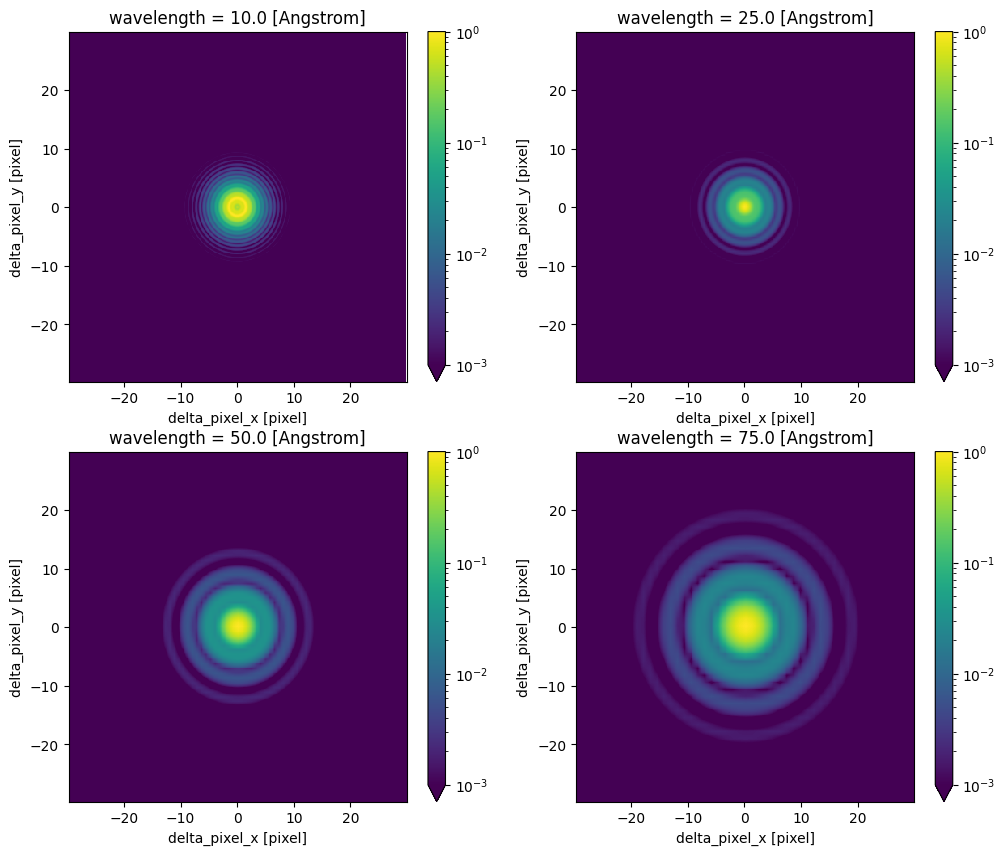

In [7]:
fig = plt.figure(figsize=(12,10))
for i,wv in enumerate(wavelengths):
    ax = fig.add_subplot(2,2,i+1)
    psf_pinhole.sel(wavelength=wv.value).plot(
        ax=ax,norm=LogNorm(vmin=1e-3,vmax=1),
        x='delta_pixel_x',
        y='delta_pixel_y'
    )

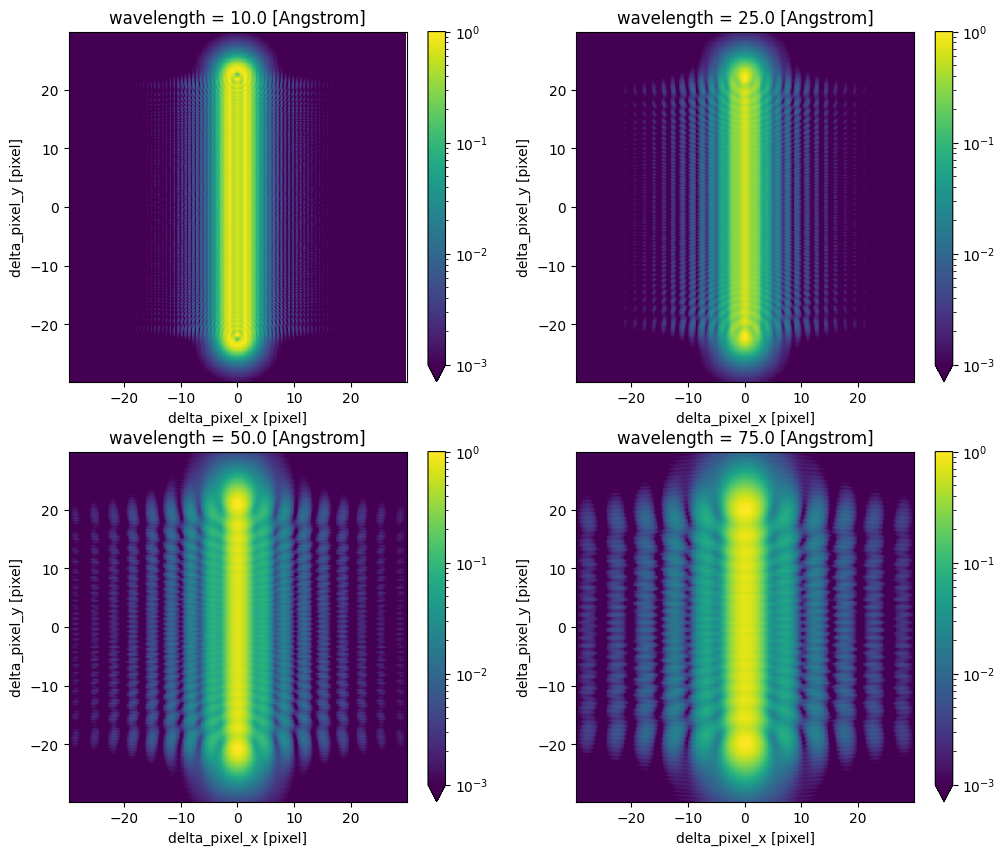

In [9]:
fig = plt.figure(figsize=(12,10))
for i,wv in enumerate(wavelengths):
    ax = fig.add_subplot(2,2,i+1)
    psf_slot.sel(wavelength=wv.value).plot(
        ax=ax,norm=LogNorm(vmin=1e-3,vmax=1),
        x='delta_pixel_x',
        y='delta_pixel_y',
    )